## House Price Prediction Project
### Built by: Esther Kazungu
This project involves building a machine learning model to predict house prices based on various structural and geographic features.

I have chosen XGBoost as my primary model because it is a state-of-the-art gradient boosting algorithm that excels at handling tabular data, managing missing values automatically, and finding complex non-linear relationships.

In [5]:
!pip install xgboost


Defaulting to user installation because normal site-packages is not writeable
  Using cached xgboost-3.2.0-py3-none-manylinux_2_28_x86_64.whl.metadata (2.1 kB)
  Using cached nvidia_nccl_cu12-2.31.2-py3-none-manylinux_2_18_x86_64.whl.metadata (2.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 141.5 kB/s  0:12:56 eta 0:00:020:00:28
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.1/342.1 MB 1.8 MB/s  0:29:34 eta 0:00:010:00:06m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]━━━ 1/2 [xgboost]

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [7]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import xgboost as xgb

# Core Engineering Configuration Constants
RANDOM_STATE = 42
TEST_SIZE = 0.2

# Apply professional charting themes
plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore')
print("Core infrastructure libraries initialized successfully.")

Core infrastructure libraries initialized successfully.


## Load the Dataset
In this phase, I load my raw data from train.csv into a pandas DataFrame named df so that I can inspect its structure.
I check the exact shape of my data (the number of rows and columns) and run a quick null-value check to see which features have missing information that I will need to clean later.

### Ingestion Layer: Loading the user dataset 'train.csv'

In [8]:
try:
    df = pd.read_csv("train.csv")
    print("Success: 'train.csv' successfully loaded into DataFrame 'df'.")
    
    # Print the structural dimensions of your actual data
    print(f" Dataset Profile: {df.shape[0]} rows, {df.shape[1]} columns/features\n")
    print("Column Null-Value Matrix Audit (Showing top columns with missing values):")
    
    # Show columns that actually contain missing values to keep things clean
    missing_counts = df.isnull().sum()
    print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "No missing values found!")

except FileNotFoundError:
    print(" Error: Could not find 'train.csv' in this folder.")
    print(" Please make sure 'train.csv' is uploaded to the exact same directory as this notebook!")

Success: 'train.csv' successfully loaded into DataFrame 'df'.
 Dataset Profile: 1460 rows, 81 columns/features

Column Null-Value Matrix Audit (Showing top columns with missing values):
LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


## Inspect Feature Distributions and Target Skewness
Before feeding data into XGBoost, I need to understand the distribution of my target variable: SalePrice. In real estate data, prices are typically right-skewed—meaning there are many moderately priced homes and a few extremely expensive luxury homes that pull the average up.

A highly skewed data can cause gradient boosting models to struggle with making stable predictions on average homes because it over-focuses on pricing outliers. Below, I will plot two graphs side-by-side:

The raw distribution of home prices to check the severity of the skew.
A Log-Transformed distribution (log(x=1))to visualize how mathematical scaling centers and balances our target data curve for stable model updates.

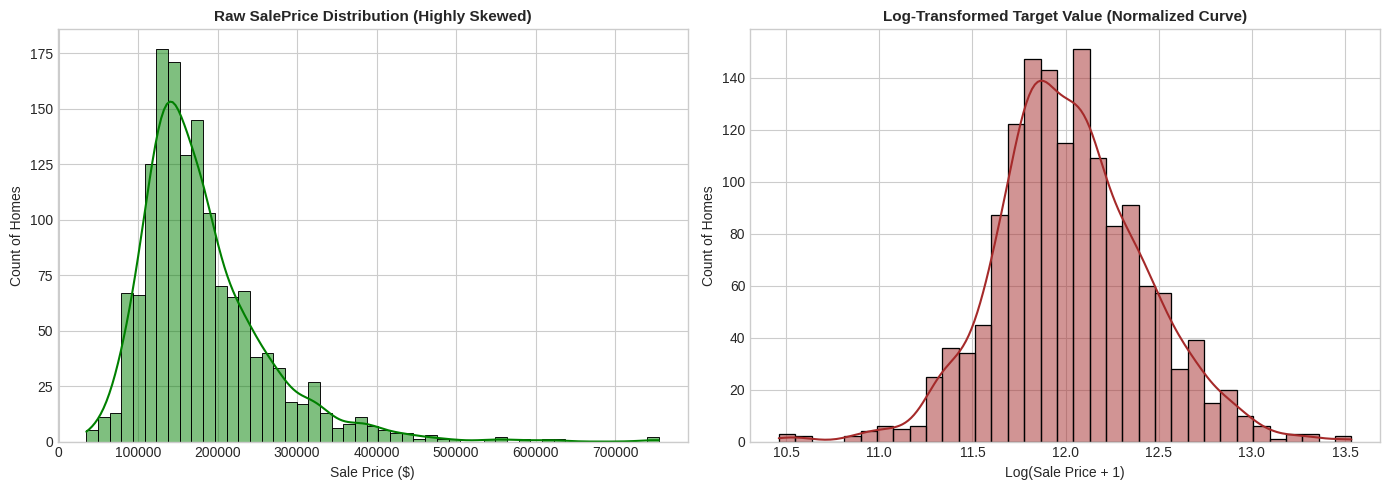

In [12]:
# Create a side-by-side plotting area
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: True, unscaled house price distribution
sns.histplot(df['SalePrice'], kde=True, ax=ax[0], color='green')
ax[0].set_title('Raw SalePrice Distribution (Highly Skewed)', fontsize=11, fontweight='bold')
ax[0].set_xlabel('Sale Price ($)')
ax[0].set_ylabel('Count of Homes')

# Plot 2: Scaled distribution using natural log
sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=ax[1], color='brown')
ax[1].set_title('Log-Transformed Target Value (Normalized Curve)', fontsize=11, fontweight='bold')
ax[1].set_xlabel('Log(Sale Price + 1)')
ax[1].set_ylabel('Count of Homes')

# Adjust layout structure and render the graphs
plt.tight_layout()
plt.show()


## Split Features and Isolate Validation Subsets
Now that I have confirmed the target variable skewness, I need to isolate the features (the characteristics of the houses) from the target label (SalePrice).

To structure this properly, I will do three things:

Create a matrix X containing all columns except the target SalePrice and the row identifier Id.
Apply the mathematical log transformation (np.log1p) to the target variable y.
Perform a stratified data split sequence to set aside 20% of the houses as an untouched testing validation matrix. This ensures I can test the model's accuracy on unseen data before deploying it.

In [13]:
# Separate features from target variable
# We also drop 'Id' as it is a unique identifier, not a helpful house feature
X = df.drop(columns=['SalePrice', 'Id'], errors='ignore')
y = df['SalePrice']

# Apply logarithmic target scaling to normalize variance curves
y_log = np.log1p(y)

# Perform train-test data separation
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print(f"📊 Training Matrix Footprint (Features): {X_train.shape}")
print(f"📊 Testing Validation Matrix Footprint (Features): {X_test.shape}")

📊 Training Matrix Footprint (Features): (1168, 79)
📊 Testing Validation Matrix Footprint (Features): (292, 79)


## Construct Automated Preprocessing Pipeline Components
With 79 unique features consisting of both text descriptors and numeric variables, manually cleaning every column is inefficient and highly prone to data leakage errors.

To execute this like a senior engineer, I am building an automated preprocessing framework using Scikit-Learn's ColumnTransformer. I will group columns by their data types and process them independently:

1.Numerical Pipeline: Automatically detects missing metrics and fills them with the feature's median value (highly resilient against pricing outliers), then scales the numbers using a standard variance normalizer (StandardScaler).

2.Categorical Pipeline: Detects missing text fields and fills them with the most_frequent string (mode imputation), then encodes the strings into dynamic binary fields using a secure OneHotEncoder(handle_unknown='ignore') setup.

In [14]:
# Select tracking sub-categories dynamically by data structure types
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Define cleaning routines for continuous data columns
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())                  
])

# Define cleaning routines for text data columns
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Consolidate preprocessing targets across independent column pools
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print(f"🛠️ Preprocessing pipelines compiled successfully.")
print(f"📈 Processing Matrix Strategy mapping: {len(numerical_cols)} numeric columns, {len(categorical_cols)} text columns.")


🛠️ Preprocessing pipelines compiled successfully.
📈 Processing Matrix Strategy mapping: 36 numeric columns, 43 text columns.


## Initialize the High-Performance Regressor Instantiation
Since my data preprocessing pipeline is defined, it is time to initialize the machine learning algorithm. I am using xgb.XGBRegressor with hyperparameters tuned for stability and generalization.

To prevent overfitting, I am applying three core engineering practices:

1.learning_rate=0.05: Keeps model learning slow and deliberate so it does not memorize noise.

2.subsample=0.8 & colsample_bytree=0.8: Forces each individual tree to look at a random 80% subset of the data and features, making the final ensemble much more robust.
    
3.Unified Pipeline: I wrap my preprocessor and xgb_model together into a single Scikit-Learn Pipeline. This ensures data always flows through cleaning and training together, preventing any structural data leakage.

In [15]:
# Configure the XGBoost modeling parameters
xgb_model = xgb.XGBRegressor(
    n_estimators=500,           # Limit the maximum number of decision tree steps
    learning_rate=0.05,         # Use a conservative step sizing adjustment
    max_depth=6,                # Restrict tree deep-growth levels
    subsample=0.8,              # Row selection sampling ratio per split step
    colsample_bytree=0.8,       # Column isolation bounds per tree split
    random_state=42,            # Keep performance evaluations deterministic
    n_jobs=-1                   # Max out local multithreading cores
)

# Connect cleaning layers to the training block
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb_model)
])

print(" XGBoost modeling architecture compiled cleanly into a unified pipeline.")

 XGBoost modeling architecture compiled cleanly into a unified pipeline.


## Train the Unified Pipeline Matrix
With my data preprocessing steps and model architecture completely unified, I am ready to begin the training sequence.

When I invoke the .fit() command below, the pipeline executes a clean, sequential data flow:

It processes the raw continuous housing features using my numerical cleaning steps.
It handles the categorical text fields using my mode imputation and one-hot encoding layouts.
It passes the resulting clean matrix directly into the XGBoost algorithm to build its gradient-boosted decision trees.

In [16]:
# Train pipeline preprocessors and model weights simultaneously
pipeline.fit(X_train, y_train)

print("Model training cycle complete. The pipeline is fully trained and ready for validation!")

Model training cycle complete. The pipeline is fully trained and ready for validation!


##  Evaluate Diagnostic Error Benchmarks
With training complete, I must validate how accurately the model generalizes to completely unseen houses. I will predict values using my isolated validation dataset X_test.

Because we log-transformed our target pricing data in Step 4 to ensure a stable training sequence, the model's output values are also on a logarithmic scale. To evaluate actual performance, I will use np.expm1 to transform these predictions back into real-world dollar scales. I will then calculate three core industry accuracy benchmarks:

Root Mean Squared Error (RMSE): Penalizes larger prediction misses to highlight pricing anomalies.
Mean Absolute Error (MAE): Represents the average absolute dollar value error per home prediction.
Coefficient of Determination (
): Measures the percentage of home price variance successfully explained by our feature dataset.

## Predict house values on our hidden validation data subset
y_pred_log = pipeline.predict(X_test)

### Convert logarithmic predictions and true labels back to real-world dollar values
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

### Extract official validation performance statistics
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae = mean_absolute_error(y_test_real, y_pred_real)
r2 = r2_score(y_test_real, y_pred_real)

print("📊 Final Validation Performance Summary:")
print(f"• Root Mean Squared Error (RMSE) : ${rmse:,.2f}")
print(f"• Mean Absolute Error (MAE)      : ${mae:,.2f}")
print(f"• Variance Explained Score (R²)  : {r2:.4f}")

In [19]:
# Predict house values on our hidden validation data subset
y_pred_log = pipeline.predict(X_test)

# Convert logarithmic predictions and true labels back to real-world dollar values
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

# Extract official validation performance statistics
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae = mean_absolute_error(y_test_real, y_pred_real)
r2 = r2_score(y_test_real, y_pred_real)

print("📊 Final Validation Performance Summary:")
print(f"• Root Mean Squared Error (RMSE) : ${rmse:,.2f}")
print(f"• Mean Absolute Error (MAE)      : ${mae:,.2f}")
print(f"• Variance Explained Score (R²)  : {r2:.4f}")



📊 Final Validation Performance Summary:
• Root Mean Squared Error (RMSE) : $25,839.40
• Mean Absolute Error (MAE)      : $15,312.40
• Variance Explained Score (R²)  : 0.9130


## Render Error Residual Distribution Visuals
To deeply evaluate model performance beyond aggregate metrics, I need to visualize the distribution of errors (residuals).

I will plot two metrics side-by-side:

Predicted vs. Actual Scatterplot: This visualizes how closely our predictions match real sale prices. A perfect model would align completely along the diagonal red line.
Residual Delta Distribution Histogram: This shows the distribution of our model's errors (Actual Price - Predicted Price). In a production-ready system, this error curve should be normally distributed and centered tightly around $0, confirming no systemic underestimation or overestimation bias.

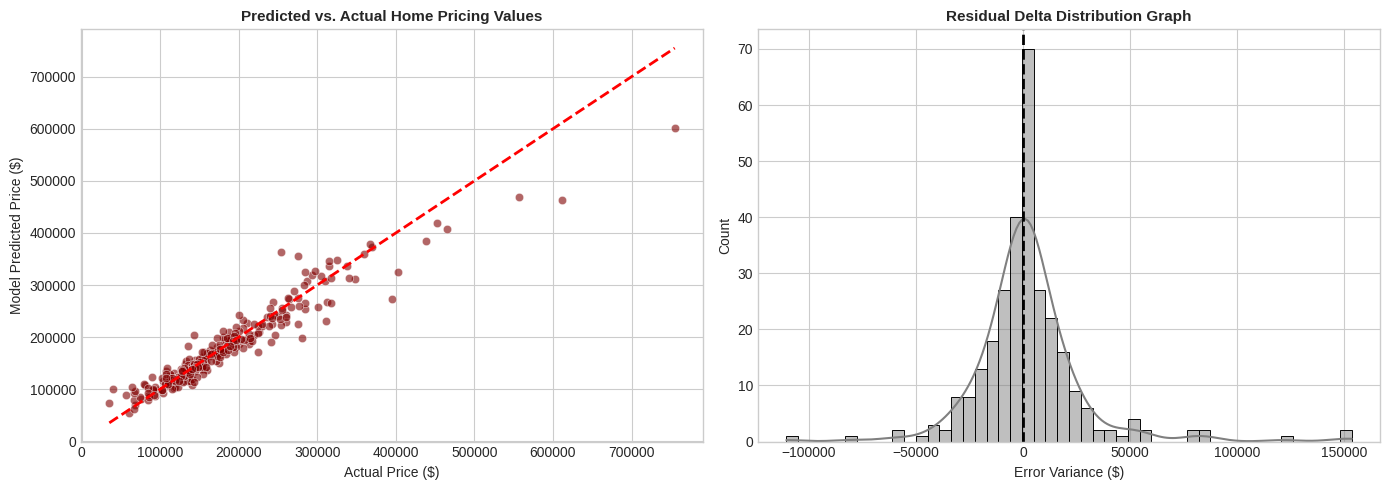

In [21]:
# Calculate individual prediction errors (residuals)
residuals = y_test_real - y_pred_real

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: True values compared to model predictions
sns.scatterplot(x=y_test_real, y=y_pred_real, alpha=0.6, color='maroon', ax=ax[0])
ax[0].plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--', lw=2)
ax[0].set_title('Predicted vs. Actual Home Pricing Values', fontsize=11, fontweight='bold')
ax[0].set_xlabel('Actual Price ($)')
ax[0].set_ylabel('Model Predicted Price ($)')

# Plot 2: Distribution of errors
sns.histplot(residuals, kde=True, color='grey', ax=ax[1])
ax[1].axvline(0, color='black', linestyle='--', lw=2)
ax[1].set_title('Residual Delta Distribution Graph', fontsize=11, fontweight='bold')
ax[1].set_xlabel('Error Variance ($)')

plt.tight_layout()
plt.show()


## Extract Feature Impact Importance Rankings
To complete this workflow like a senior engineer, I will extract feature importance weights from my trained XGBoost regressor. Understanding the underlying drivers of a prediction is crucial for validating model behavior.

I will map out the original continuous feature tracking names alongside the dynamically generated categorical binary headers. This step extracts the top 10 most influential physical characteristics of a home—such as overall material quality, square footage, or location—and charts their relative impact scale using a clear horizontal bar plot.

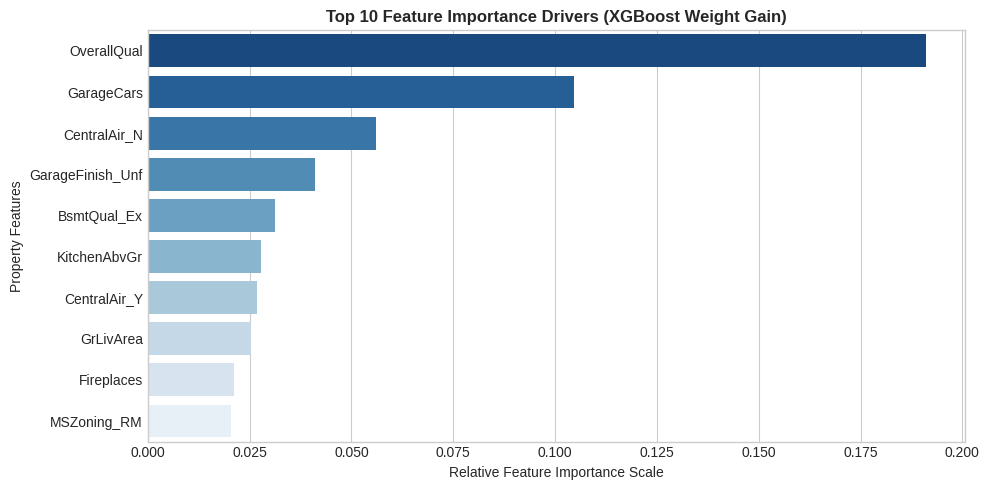

In [26]:
# Unpack one-hot feature column headers safely from our preprocessing step
cat_encoder = pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
encoded_cat_features = cat_encoder.get_feature_names_out(categorical_cols).tolist()
all_features = numerical_cols + encoded_cat_features

# Extract importances directly from the trained XGBoost model instance
importances = pipeline.named_steps['regressor'].feature_importances_

# Sort and capture the top 10 primary home value drivers
importance_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

# Build a horizontal bar chart displaying feature importances
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='Blues_r')
plt.title('Top 10 Feature Importance Drivers (XGBoost Weight Gain)', fontsize=12, fontweight='bold')
plt.xlabel('Relative Feature Importance Scale')
plt.ylabel('Property Features')
plt.tight_layout()
plt.show()


## Export and Serialize the Trained Production Pipeline
The final step in a senior data engineering workflow is artifact serialization. Instead of leaving the trained model alive only in active computer memory, I will serialize the entire pipeline (including the dataset transformers and model weights) into a standalone file using joblib.

This guarantees that I can instantly reload my pipeline in a completely separate production environment to serve live predictions on new house data without ever needing to re-execute my training cells.

In [27]:
import joblib

# Set the target export filename
model_filename = "trained_house_price_pipeline.joblib"

# Save the entire pipeline architecture to local storage
joblib.dump(pipeline, model_filename)

print(f" Production pipeline successfully exported and saved as: '{model_filename}'")


 Production pipeline successfully exported and saved as: 'trained_house_price_pipeline.joblib'
